<img src="imgs/unifor_logo.png" width="400">
<br>
<b>
<font size="6" face="arial" color="blue">
    Graduação em Ciência da Computação
</font>
</b>
<br>
<b>
<font size="4" face="arial">
    Disciplina: Métodos Quantitativos para Computação
</font>
</b>

**Orientador: Prof. Me. Ricardo Carubbi** <br>
*Docente da Graduação e Pós-Graduação em Ciência de Dados e Inteligência Artificial*<br>
*Laboratório de Ciência de Dados e Inteligência Artificial*<br>
*Universidade de Fortaleza*<br>

<p dir="ltr" style="text-align: left;">
    <strong>Links:</strong>
    <a href="https://www2.unifor.br/controle_pesquisa/pesquisarprofessor.do?actionParameter=prepareUpdate&amp;p_tp_ambiente=2&amp;p_tp_chamada=1&amp;p_tp_apresentacao=1&amp;cdPesquisador=767686193" target="_blank">Unifor</a> |
    <a href="http://lattes.cnpq.br/5738786447903616" target="_blank">Lattes</a> |
    <a href="https://unifor.br/web/pesquisa-inovacao/ncdia" target="_blank">NCDIA</a> |
    <a href="https://github.com/carubbi/" target="_blank">Github</a>
</p>

# **Teorema de Bayes**

## Em frente!

Neste notebook, vamos trabalhar três relações entre **conjunção** e **probabilidade condicional**:

* **Definição de probabilidade condicional:** Usando a conjunção para calcular uma probabilidade condicional.

* **Regra do Produto:** Usando uma probabilidade condicional para calcular uma conjunção.

* **Teorema de Bayes:** Usando `prob_cond(A, B)` para calcular `prob_cond(B, A)`.

O **Teorema de Bayes** é uma das bases da estatística Bayesiana.

Em algumas partes deste notebook será útil usar notação matemática para probabilidade, então vou introduzi-la agora:

* $P(A)$ é a probabilidade da proposição $A$.

* $P(A \cap B)$ é a probabilidade da conjunção de $A$ e $B$, ou seja, a probabilidade de que ambos sejam verdadeiros.

* $P(A \mid B)$ é a probabilidade condicional de $A$ dado que $B$ é verdadeiro.  
  A barra vertical entre $A$ e $B$ é lida como **“dado que”**.

Com isso, estamos prontos para a **definição de probabilidade condicional**.

In [1]:
# Importando as bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Revisão

[No notebook anterior](aulas/notebooks/6_PRB.ipynb) defini **probabilidade**, **conjunção** e **probabilidade condicional**, e usei dados da *General Social Survey (GSS)* para calcular a probabilidade de várias proposições lógicas.

Para revisar, aqui está como carregamos o conjunto de dados:

In [2]:
# Carregando o dataset
gss = pd.read_csv('../../dataset/gss_bayes.csv')
gss.head()

,caseid,year,age,sex,polviews,partyid,indus10
0,1,1974,21.0,1,4.0,2.0,4970.0
1,2,1974,41.0,1,5.0,0.0,9160.0
2,5,1974,58.0,2,6.0,1.0,2670.0
3,6,1974,30.0,1,5.0,4.0,6870.0
4,7,1974,48.0,1,5.0,4.0,7860.0


In [3]:
# Renomeando as colunas para facilitar a manipulação
gss.rename(columns={
    'caseid': 'id',
    'year': 'ano',
    'age': 'idade',
    'sex': 'sexo',
    'polviews': 'visao_pol',
    'partyid': 'partido',
    'indus10': 'setor',
}, inplace=True)

gss.head()

,id,ano,idade,sexo,visao_pol,partido,setor
0,1,1974,21.0,1,4.0,2.0,4970.0
1,2,1974,41.0,1,5.0,0.0,9160.0
2,5,1974,58.0,2,6.0,1.0,2670.0
3,6,1974,30.0,1,5.0,4.0,6870.0
4,7,1974,48.0,1,5.0,4.0,7860.0


In [4]:
# Exibindo informações básicas sobre o dataset
gss.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49290 entries, 0 to 49289
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         49290 non-null  int64  
 1   ano        49290 non-null  int64  
 2   idade      49290 non-null  float64
 3   sexo       49290 non-null  int64  
 4   visao_pol  49290 non-null  float64
 5   partido    49290 non-null  float64
 6   setor      49290 non-null  float64
dtypes: float64(4), int64(3)
memory usage: 2.6 MB


As colunas são:

* `id`: identificador do respondente.
* `ano`: ano da entrevista.
* `idade`: idade do respondente na entrevista.
* `sexo`: sexo do respondente.
* `visao_pol`: posicionamento político em uma escala de liberal a conservador.
* `partido`: identificação partidária do respondente.
* `setor`: [código](https://www.census.gov/cgi-bin/sssd/naics/naicsrch?chart=2007) do setor de atividade econômica em que o respondente trabalha.

Vamos analisar essas variáveis em mais detalhes, começando por `setor`.

Aqui estão as proposições lógicas que definimos, representadas por séries booleanas.

In [5]:
setor_bancario = (gss['setor'] == 6870)
setor_bancario.value_counts()

setor
False    48562
True       728
Name: count, dtype: int64

In [59]:
feminino = (gss['sexo'] == 2)
feminino.value_counts() 

sexo
True     26511
False    22779
Name: count, dtype: int64

In [60]:
liberal = (gss['visao_pol'] < 4)
liberal.value_counts()

visao_pol
False    35797
True     13493
Name: count, dtype: int64

In [61]:
democrata = (gss['partido'] <= 1)
democrata.value_counts()

partido
False    31237
True     18053
Name: count, dtype: int64

Defini a seguinte função, que usa `mean` para calcular a fração de valores `True` em uma série booleana.

In [9]:
def prob(A):
    """Calcula a probabilidade de uma proposição A.
    A: série booleana
    retorna: probabilidade
    """
    assert isinstance(A, pd.Series)
    assert A.dtype == 'bool'

    return A.sum()/A.size # equivalente a A.mean()

Assim, podemos calcular a probabilidade de uma proposição desta forma:

In [10]:
prob(feminino)

np.float64(0.5378575776019476)

Então usamos o operador `&` para calcular a **probabilidade de uma conjunção**, assim:

In [11]:
prob(feminino & setor_bancario)

np.float64(0.011381618989653074)

Em seguida, defini a seguinte função, que usa o operador de colchetes para calcular a **probabilidade condicional**:

In [12]:
def prob_cond(A, B):
    """Calcula a probabilidade condicional de A dado B.

    A: série booleana
    B: série booleana

    retorna: probabilidade
    """
    return prob(A[B])

Mostramos que a conjunção é comutativa, portanto `prob(A & B)` é igual a `prob(B & A)`, para quaisquer proposições lógicas `A` e `B`.

Por exemplo:

In [13]:
prob(liberal & democrata)

np.float64(0.1425238385067965)

In [14]:
prob(democrata & liberal)

np.float64(0.1425238385067965)

Mas a **probabilidade condicional NÃO é comutativa**, portanto `prob_cond(A, B)` geralmente não é o mesmo que `prob_cond(B, A)`.

Por exemplo, aqui está a probabilidade de que um entrevistado seja mulher, dado que ele seja bancário.

In [15]:
prob_cond(feminino, setor_bancario)

np.float64(0.7706043956043956)

E aqui está a probabilidade de que um entrevistado seja bancário, dado que seja mulher.

In [16]:
prob_cond(setor_bancario, feminino)

np.float64(0.02116102749801969)

Nem de perto.

## Mais proposições

Para variar nossos **exemplos**, vamos definir algumas novas proposições.

Aqui está a probabilidade de que um entrevistado aleatório seja homem.

In [17]:
masculino = (gss['sexo']==1)
prob(masculino)

np.float64(0.46214242239805237)

O código do setor de **“Construção”** é `770`.  
Vamos chamar alguém desta área de **“construtor”**.

In [18]:
construtor = (gss['setor'] == 770)
prob(construtor)

np.float64(0.05978900385473727)

E vamos definir proposições para **conservadores** e **republicanos**.

In [19]:
conservador = (gss['visao_pol'] > 4)
prob(conservador)

np.float64(0.3419354838709677)

In [20]:
republicano = (gss['partido'].isin([5,6]))
prob(republicano)

np.float64(0.2610062893081761)

Por fim, usarei `idade` para definir as proposições `jovem` e `idoso`.

In [21]:
jovem = (gss['idade'] < 30)
prob(jovem)

np.float64(0.19435991073240008)

In [22]:
idoso = (gss['idade'] >= 65)
prob(idoso)

np.float64(0.17328058429701765)

Para esses limites, escolhi números arredondados próximos aos percentis 20 e 80.  
Dependendo da sua idade, você pode ou não concordar com essas definições de *“jovem”* e *“idoso”*.

**Exercício:** Há uma [citação famosa](https://quoteinvestigator.com/2014/02/24/heart-head/) sobre jovens, pessoas idosas, liberais e conservadores que diz algo como:

> Se você não é liberal aos 25 anos, não tem coração.  
> Se você não é conservador aos 35 anos, não tem cérebro.

Concordando ou não com essa proposição, ela sugere algumas probabilidades que podemos calcular como um exercício de revisão.  
Use `prob` e `prob_cond` para calcular essas probabilidades.

* Qual é a **probabilidade** de que um entrevistado escolhido aleatoriamente seja um **jovem liberal**?

* Qual é a **probabilidade** de que uma **pessoa jovem** seja **liberal**?

* Que **fração** dos entrevistados são **idosos conservadores**?

* Que **fração** dos **conservadores** são **idosos**?

Para cada enunciado, pense se ele expressa uma **conjunção**, uma **probabilidade condicional** ou ambos.

E, nas probabilidades condicionais, **cuidado com a ordem**!

In [ ]:
# Probabilidade de ser jovem e liberal
prob(jovem & liberal)

np.float64(0.06579427875836884)

In [ ]:
# Probabilidade de liberal dado que é jovem
prob_cond(liberal, jovem)

np.float64(0.338517745302714)

In [ ]:
# Probabilidade de ser idoso e conservador
prob(idoso & conservador)

np.float64(0.06701156421180766)

In [ ]:
# Probabilidade de ser idoso dado que é conservador
prob_cond(idoso, conservador)

np.float64(0.19597721609113564)

Se a sua última resposta for maior que **30%**, você colocou ao contrário!

## Em frente!

Neste notebook, vamos trabalhar três relações entre **conjunção** e **probabilidade condicional**:

* **Definição de probabilidade condicional:** Usando a conjunção para calcular uma probabilidade condicional.

* **Regra do Produto:** Usando uma probabilidade condicional para calcular uma conjunção.

* **Teorema de Bayes:** Usando `prob_cond(A, B)` para calcular `prob_cond(B, A)`.

O **Teorema de Bayes** é uma das bases da estatística Bayesiana.

Em algumas partes deste notebook será útil usar notação matemática para probabilidade, então vou introduzi-la agora:

* $P(A)$ é a probabilidade da proposição $A$.

* $P(A \cap B)$ é a probabilidade da conjunção de $A$ e $B$, ou seja, a probabilidade de que ambos sejam verdadeiros.

* $P(A \mid B)$ é a probabilidade condicional de $A$ dado que $B$ é verdadeiro.  
  A barra vertical entre $A$ e $B$ é lida como **“dado que”**.

Com isso, estamos prontos para a **definição de probabilidade condicional**.

## Definição de Probabilidade Condicional

Calcule a probabilidade de ser **homem** dado que o entrevistado é **construtor**.  
Já vimos uma maneira de calcular a resposta:

1. Usar o operador de colchetes para selecionar os construtores, depois  

2. Usar `mean` para calcular a probabilidade de ser homem dado que o entrevistado é construtor.

Podemos escrever esses passos assim:

In [65]:
# masculino[construtor].mean()
masculino[construtor].sum()/masculino[construtor].size

np.float64(0.8920936545639634)

Ou podemos usar a função `prob_cond`, que faz a mesma coisa:

In [ ]:
# Probabilidade de ser do gênero masculino dado que é construtor
prob_cond(masculino, construtor)

np.float64(0.8920936545639634)

Mas há outra maneira: para calcular a probabilidade de ser homem dado que o entrevistado é construtor, podemos calcular a razão entre duas probabilidades:

1. A fração dos entrevistados que são **homens construtores**, e  

2. A fração dos entrevistados que são **construtores**.

Aqui está como isso fica:

In [29]:
prob(masculino & construtor) / prob(construtor)

np.float64(0.8920936545639634)

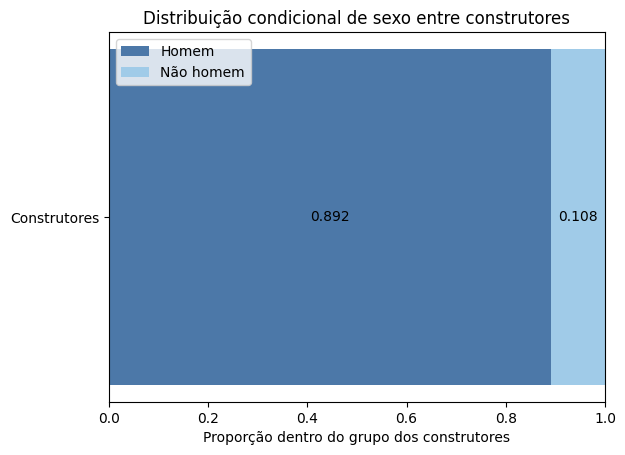

In [30]:
# Representa, entre os construtores, as frações de homens e não homens
p_homem_dado_construtor = prob_cond(masculino, construtor)
p_nao_homem_dado_construtor = 1 - p_homem_dado_construtor

plt.barh(
    ['Construtores'],
    [p_homem_dado_construtor],
    color='#4C78A8',
    label='Homem'
)
plt.barh(
    ['Construtores'],
    [p_nao_homem_dado_construtor],
    left=[p_homem_dado_construtor],
    color='#A0CBE8',
    label='Não homem'
)

plt.text(
    p_homem_dado_construtor / 2,
    0,
    f'{p_homem_dado_construtor:.3f}',
    ha='center',
    va='center'
)
plt.text(
    p_homem_dado_construtor + p_nao_homem_dado_construtor / 2,
    0,
    f'{p_nao_homem_dado_construtor:.3f}',
    ha='center',
    va='center'
)

plt.xlim(0, 1)
plt.xlabel('Proporção dentro do grupo dos construtores')
plt.title('Distribuição condicional de sexo entre construtores')
plt.legend()
plt.show()

Fig. 1 - Distribuição condicional de sexo entre construtores. O gráfico mostra o espaço de referência restrito ao grupo dos construtores, evidenciando que a probabilidade condicional corresponde à fração de homens dentro desse subconjunto. Fonte: Carubbo, 2026.

O resultado é o mesmo.

Este **exemplo** demonstra uma regra geral que relaciona **probabilidade condicional** e **conjunção**.  
Em notação matemática, isso fica assim:

$$
P(A \mid B) = \frac{P(A \cap B)}{P(B)}, \quad P(B) > 0 \tag{Def. 1}
$$

E essa é a **definição de probabilidade condicional**.

Neste exemplo:

`prob_cond(masculino, construtor) = prob(masculino & construtor) / prob(construtor)`

**Exercício:** Calcule a probabilidade de ser **republicano** dado que o entrevistado é **conservador**. Calcule a resposta de duas maneiras:

* Usando `prob_cond` (que por baixo dos panos utiliza o operador de colchetes), e
* Usando a **definição de probabilidade condicional**.

Confirme que você obtém o mesmo resultado.

**Observação:** Devido à aritmética de ponto flutuante, os resultados podem não ser exatamente idênticos, mas quase todos os dígitos.

In [ ]:
# Probabilidade de ser republicano dado que é conservador
prob_cond(republicano, conservador)

np.float64(0.45027886555120444)

In [66]:
# Probabilidade de ser conservador e republicano dividido pela probabilidade de ser conservador
prob(conservador & republicano) / prob(conservador)

np.float64(0.4502788655512045)

## Prova?

Eu não cheguei a **provar** essa fórmula; em essência, ela é uma afirmação sobre o que **probabilidade condicional** significa.

Por exemplo, considere este diagrama de Venn:

<img width="200" src="https://github.com/AllenDowney/BiteSizeBayes/raw/master/theorem1_venn_diagram.png">

O círculo azul representa os respondentes **homens**.  
O círculo vermelho representa os **construtores**.  
A interseção representa os **homens construtores**.

Para calcular a probabilidade de ser homem dado que o entrevistado é construtor, tomamos a razão entre a **interseção**, que é `prob(masculino & construtor)`, e o círculo **vermelho**, que é `prob(construtor)`. O resultado é `prob(masculino | construtor)`, isto é, a probabilidade de uma pessoa ser homem dado que sabemos que ela é do setor da construção.

**Exercício:** Para praticar, calcule a probabilidade de ser **idoso** dado que o entrevistado é do **setor bancário** de duas formas: usando `prob_cond` e usando a **definição de probabilidade condicional**.

In [ ]:
# Probabilidade de ser idoso dado que é do setor bancário
prob_cond(idoso, setor_bancario)

np.float64(0.14697802197802198)

In [ ]:
# Probabilidade de ser idoso e do setor bancário dividido pela probabilidade de ser do setor bancário
prob(idoso & setor_bancario) / prob(setor_bancario)

np.float64(0.14697802197802198)

## Regra do Produto

Queremos calcular a probabilidade de que um entrevistado seja **conservador e republicano**.

Já vimos uma maneira direta de fazer isso: usar a **conjunção** entre duas proposições e, em seguida, calcular a probabilidade do resultado. Em notação do notebook, isso equivale a calcular `prob(conservador & republicano)`.

Mas existe uma segunda estratégia. Podemos começar pela probabilidade de um entrevistado ser **republicano** e, depois, restringir a análise à fração dos republicanos que também são **conservadores**. Essa segunda forma conduz à **regra do produto**.

Aqui está o resultado usando `&`:

In [ ]:
# Probabilidade de ser conservador e republicano
prob(conservador & republicano)

np.float64(0.15396632176912153)

E aqui está o resultado usando a **regra do produto**:

In [36]:
prob(republicano) * prob_cond(conservador, republicano)

np.float64(0.1539663217691215)

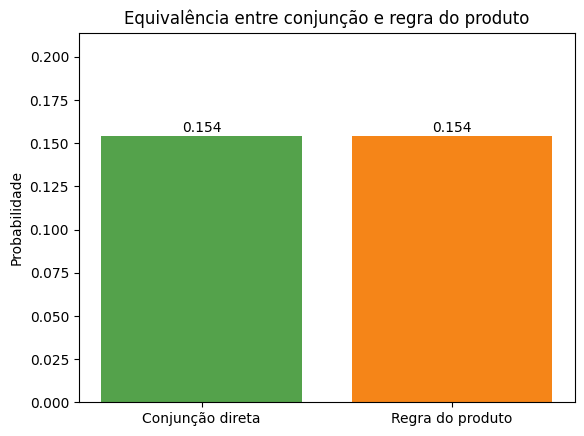

In [37]:
# Compara a conjunção direta com o cálculo via regra do produto
valores_produto = {
    'Conjunção direta': prob(conservador & republicano),
    'Regra do produto': (
        prob(republicano) * prob_cond(conservador, republicano)
    ),
}

barras = plt.bar(
    valores_produto.keys(),
    valores_produto.values(),
    color=['#54A24B', '#F58518']
)

for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        altura + 0.0025,
        f'{altura:.3f}',
        ha='center'
    )

plt.ylabel('Probabilidade')
plt.ylim(0, max(valores_produto.values()) + 0.06)
plt.title('Equivalência entre conjunção e regra do produto')
plt.show()

Fig. 2 - Equivalência entre conjunção e regra do produto. As duas barras praticamente coincidem, mostrando que a probabilidade do evento `conservador e republicano` pode ser obtida tanto diretamente quanto pela decomposição $P(B)P(A \mid B)$. Fonte: Carubbo, 2026.

Os resultados coincidem, exceto por pequenas diferenças numéricas de arredondamento. Isso ilustra a relação geral

$$
P(A \mid B) = \frac{P(A \cap B)}{P(B)} \;\Rightarrow\; P(A \cap B) = P(B)\,P(A \mid B) \tag{Teo. 1}
$$

que chamamos de **Teorema 1** ou **regra do produto**.


Para três eventos, A, B e C, a regra do produto pode ser escrita como

$$
P(A \cap B \cap C) = P(A)\,P(B \mid A)\,P(C \mid A \cap B)
$$

**Exercício:** Verifique a **regra do produto** mais uma vez calculando a fração de entrevistados que são **idosos liberais** de duas formas:

* Usando o operador `&`, e
* Usando a **regra do produto**.

Os resultados devem ser iguais ou, pelo menos, **muito próximos**.

In [38]:
prob(idoso & liberal)

np.float64(0.03653885169405559)

In [39]:
prob(liberal) * prob_cond(idoso, liberal)

np.float64(0.03653885169405559)

**Exercício:** Calcule a probabilidade de um entrevistado ser **jovem, liberal e republicano** de duas maneiras:

* Usando o operador `&`, e
* Usando a **regra do produto**.

In [ ]:
# Usando conjunção direta
prob(jovem & liberal & republicano)

np.float64(0.007993507810914994)

In [128]:
# Usando a regra do produto
prob(jovem) * prob_cond(liberal, jovem) * prob_cond(republicano, jovem & liberal)

np.float64(0.007993507810914994)

## Conjunção é comutativa

Já estabelecemos que a **conjunção é comutativa**. Em notação matemática, isso significa:

$$
P(A \cap B) = P(B \cap A)
$$

Se aplicarmos a **regra do produto** aos dois lados, temos:

$$
P(B)\, P(A \mid B) = P(A)\, P(B \mid A)
$$

Uma forma de interpretar isso é: se você quer verificar $A$ e $B$, pode fazê-lo em **qualquer ordem**:

1. Você pode verificar **$B$ primeiro**, depois **$A$ condicionado a $B$**, ou  
2. Você pode verificar **$A$ primeiro**, depois **$B$ condicionado a $A$**.

Para experimentar, vou calcular a probabilidade de um entrevistado ser **jovem e construtor** das duas maneiras:

In [40]:
prob(jovem) * prob_cond(construtor, jovem)

np.float64(0.012314871170622844)

In [41]:
prob(construtor) * prob_cond(jovem, construtor)

np.float64(0.012314871170622844)

Mesma coisa!

**Exercício:** Calcule a probabilidade de um entrevistado ser **homem e bancário** das duas maneiras e veja se você obtém o mesmo resultado.

In [42]:
prob(setor_bancario) * prob_cond(masculino, setor_bancario)

np.float64(0.003388111178738081)

In [43]:
prob(masculino) * prob_cond(setor_bancario, masculino)

np.float64(0.003388111178738081)

## Eventos Independentes

Dois eventos $A$ e $B$ são ditos **independentes** quando a ocorrência de um não altera a probabilidade do outro. Em termos de probabilidade condicional, isso significa que

$$
P(A \mid B)=P(A),
$$

desde que $P(B)>0$. Substituindo essa igualdade na **regra do produto**, obtemos uma caracterização equivalente da independência:

$$
P(A \cap B)=P(A)P(B).
$$

Essa relação é importante porque simplifica o cálculo de probabilidades conjuntas quando os eventos são independentes. No entanto, é importante não confundir **eventos independentes** com **eventos mutuamente exclusivos**. Um exemplo simples de eventos mutuamente exclusivos é obter **cara** e obter **coroa** em um único lançamento de moeda: os dois resultados não podem ocorrer ao mesmo tempo. Se dois eventos mutuamente exclusivos têm probabilidade positiva, então a ocorrência de um impede a ocorrência do outro; portanto, eles não são independentes.

Com dados observacionais finitos, normalmente não provamos independência; no máximo, verificamos se a relação $P(A \cap B) \approx P(A)P(B)$ parece plausível para os eventos analisados.

Vamos ilustrar essa ideia com os eventos **jovem** e **republicano**. Primeiro, calculamos diretamente a probabilidade da conjunção:

In [ ]:
# Usando conjunção direta
prob(jovem & republicano)

np.float64(0.045323595049705824)

Agora calculamos o produto das **probabilidades marginais** (isto é, das probabilidades de cada evento considerado isoladamente, sem condicionar em outro):

In [ ]:
# Produto das probabilidades marginais
prob(jovem) * prob(republicano)

np.float64(0.0507291590905321)

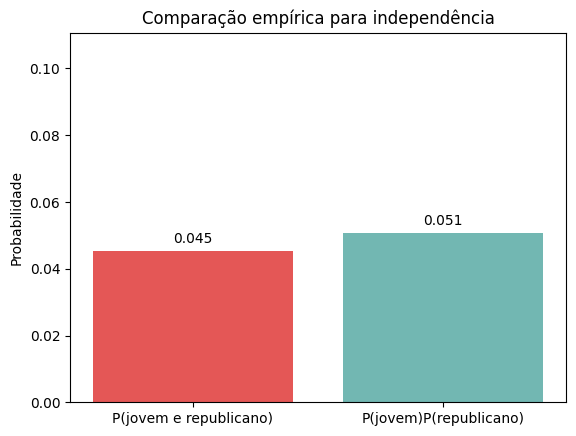

In [46]:
# Compara a conjunção observada com o produto das probabilidades marginais
valores_independencia = {
    'P(jovem e republicano)': prob(jovem & republicano),
    'P(jovem)P(republicano)': prob(jovem) * prob(republicano),
}

barras = plt.bar(
    valores_independencia.keys(),
    valores_independencia.values(),
    color=['#E45756', '#72B7B2']
)

for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        altura + 0.0025,
        f'{altura:.3f}',
        ha='center'
    )

plt.ylabel('Probabilidade')
plt.ylim(0, max(valores_independencia.values()) + 0.06)
plt.title('Comparação empírica para independência')
plt.show()

Fig. 3 - Comparação empírica para independência. O gráfico contrapõe a probabilidade observada da conjunção `jovem e republicano` ao produto das probabilidades marginais; a proximidade ou distância entre as barras sugere maior ou menor plausibilidade de independência. Fonte: Carubbo, 2026.

Se os valores fossem exatamente iguais, isso seria compatível com independência perfeita. Em dados observacionais finitos, o mais prudente é interpretar essa comparação como uma **verificação empírica aproximada**, e não como prova formal de independência.

**Exercício:** Compare agora os eventos **feminino** e **liberal**. Calcule `prob(feminino & liberal)` e compare com `prob(feminino) * prob(liberal)`. Os valores sugerem independência plausível ou dependência entre os eventos?

In [ ]:
# Usando conjunção direta
prob(feminino & liberal)

np.float64(0.14834652059241227)

In [ ]:
# Produto das probabilidades marginais
prob(feminino) * prob(liberal)

np.float64(0.14723701145431284)

## Teorema de Bayes

Agora queremos calcular a probabilidade de que um entrevistado seja **liberal**, dado que ele é **construtor**.

Uma maneira de fazer isso é direta: usar `prob_cond(liberal, construtor)`. Mas também podemos calcular essa mesma quantidade por outro caminho, começando por `P(liberal)` e ajustando essa probabilidade pela chance de um liberal ser construtor.

In [49]:
prob_cond(liberal, construtor)

np.float64(0.24431625381744146)

Agora, calculamos a mesma quantidade usando o **Teorema de Bayes**:

In [50]:
prob(liberal) * prob_cond(construtor, liberal) / prob(construtor)

np.float64(0.24431625381744151)

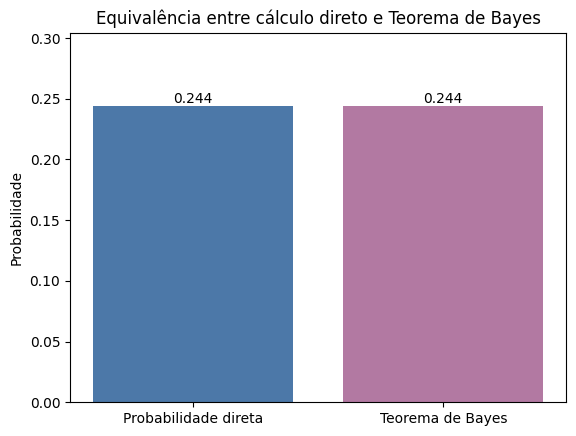

In [51]:
# Compara a probabilidade condicional direta com o cálculo via Bayes
valores_bayes = {
    'Probabilidade direta': prob_cond(liberal, construtor),
    'Teorema de Bayes': (
        prob(liberal) * prob_cond(construtor, liberal)
        / prob(construtor)
    ),
}

barras = plt.bar(
    valores_bayes.keys(),
    valores_bayes.values(),
    color=['#4C78A8', '#B279A2']
)

for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        altura + 0.0025,
        f'{altura:.3f}',
        ha='center'
    )

plt.ylabel('Probabilidade')
plt.ylim(0, max(valores_bayes.values()) + 0.06)
plt.title('Equivalência entre cálculo direto e Teorema de Bayes')
plt.show()

Fig. 4 - Equivalência entre cálculo direto e Teorema de Bayes. As duas barras mostram o mesmo valor para `P(liberal \mid construtor)`, evidenciando que o teorema recupera a probabilidade condicional a partir de probabilidades marginais e condicionais invertidas. Fonte: Carubbo, 2026.

Essa segunda estratégia leva ao **Teorema de Bayes**. A cadeia lógica é a seguinte:

1. Pela **Definição 1**, temos

$$
P(A \mid B) = \frac{P(A \cap B)}{P(B)}.
$$

2. Pelo **Teorema 1** (regra do produto), também podemos escrever a mesma conjunção como

$$
P(A \cap B) = P(A)\,P(B \mid A).
$$

3. Substituindo essa expressão da conjunção na definição de probabilidade condicional, obtemos

$$
P(A \mid B) = \frac{P(A)\,P(B \mid A)}{P(B)} \tag{Teo. 2}
$$

Ou seja, o **Teorema de Bayes** decorre da definição de probabilidade condicional combinada com a regra do produto.

**Exercício:** Tente você mesmo! Calcule a probabilidade de ser **republicano** dado que o entrevistado é **jovem** de duas maneiras: usando `prob_cond` e usando o **Teorema de Bayes**. Veja se você obtém o mesmo resultado.

In [129]:
# Usando probabilidade condicional direta
prob_cond(republicano, jovem)

np.float64(0.23319415448851774)

In [ ]:
# Usando o Teorema de Bayes
prob(republicano) * prob_cond(jovem, republicano) / prob(jovem)

np.float64(0.2331941544885177)

## Teorema da Probabilidade Total

Agora queremos responder à seguinte pergunta: **qual é a probabilidade de que um entrevistado seja jovem?**

Uma maneira de obter essa resposta é calcular diretamente `prob(jovem)`. Mas também podemos decompor essa probabilidade em grupos que formam uma **partição** do espaço amostral.

Uma coleção de eventos $A_1, A_2, \ldots, A_k$ forma uma partição de $\Omega$ quando:

* os eventos são **mutuamente exclusivos**;
* a união de todos eles corresponde ao espaço amostral completo.

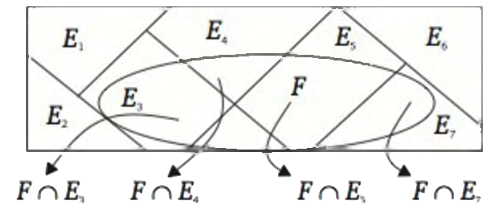

**Fig. 5 - Partição do espaço amostral em eventos mutuamente exclusivos**. A figura ilustra a ideia geral de uma partição por eventos $A_1, A_2, \ldots, A_k$: os conjuntos são mutuamente exclusivos e, juntos, cobrem todo o espaço amostral $\Omega$.

Se $A_1, A_2, \ldots, A_k$ formam uma partição de $\Omega$, então, para qualquer evento $B$,

$$
P(B) = \sum_{i=1}^{k} P(B \mid A_i)\,P(A_i).
$$

No contexto do **Teorema de Bayes**,

$$
P(B \mid E) = \frac{P(B)\,P(E \mid B)}{P(E)}.
$$

Esse resultado é especialmente importante porque o denominador $P(E)$ muitas vezes não é conhecido diretamente. Nesses casos, podemos calculá-lo pelo **Teorema da Probabilidade Total**, somando, ao longo de uma partição do espaço amostral, os termos $P(E \mid A_i)P(A_i)$.

Por exemplo, se dividirmos a população em **republicanos** e **não republicanos**, então temos uma partição com dois grupos mutuamente exclusivos que cobrem toda a população. Nesse caso, a probabilidade de um entrevistado ser **jovem** pode ser escrita como

$$
P(\text{jovem}) = P(\text{jovem} \mid \text{republicano})P(\text{republicano}) + P(\text{jovem} \mid \text{não republicano})P(\text{não republicano}).
$$

Essa decomposição mostra como a probabilidade total complementa naturalmente a **regra do produto** e o **Teorema de Bayes**.

Vamos verificar essa ideia com os dados do notebook. Primeiro, calculamos diretamente a probabilidade de um entrevistado ser **jovem**:

In [54]:
prob(jovem)

np.float64(0.19435991073240008)

Agora calculamos a mesma quantidade usando a partição formada por **republicanos** e **não republicanos**:

In [55]:
prob_cond(jovem, republicano) * prob(republicano) + \
prob_cond(jovem, ~republicano) * prob(~republicano)

np.float64(0.19435991073240008)

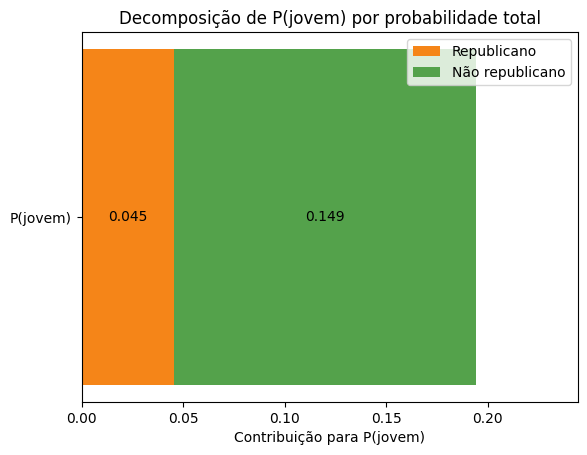

In [56]:
# Decompõe P(jovem) nas contribuições da partição republicano/não
p_jovem_republicano = (
    prob_cond(jovem, republicano) * prob(republicano)
)
p_jovem_nao_republicano = (
    prob_cond(jovem, ~republicano) * prob(~republicano)
)

plt.barh(
    ['P(jovem)'],
    [p_jovem_republicano],
    color='#F58518',
    label='Republicano'
)
plt.barh(
    ['P(jovem)'],
    [p_jovem_nao_republicano],
    left=[p_jovem_republicano],
    color='#54A24B',
    label='Não republicano'
)

plt.text(
    p_jovem_republicano / 2,
    0,
    f'{p_jovem_republicano:.3f}',
    ha='center',
    va='center'
)
plt.text(
    p_jovem_republicano + p_jovem_nao_republicano / 2,
    0,
    f'{p_jovem_nao_republicano:.3f}',
    ha='center',
    va='center'
)

plt.xlim(0, prob(jovem) + 0.05)
plt.xlabel('Contribuição para P(jovem)')
plt.title('Decomposição de P(jovem) por probabilidade total')
plt.legend()
plt.show()

**Fig. 6 - Decomposição de `P(jovem)` por probabilidade total**. A barra mostra que a probabilidade total de um entrevistado ser jovem pode ser obtida como soma das contribuições associadas aos grupos `republicano` e `não republicano`, que formam uma partição do espaço amostral. Fonte: Carubbo, 2026.

Os resultados devem coincidir, confirmando numericamente o **Teorema da Probabilidade Total** para essa partição.

**Exercício:** Repita o procedimento para calcular a probabilidade de um entrevistado ser **idoso**. Faça isso de duas maneiras:

* diretamente, usando `prob(idoso)`;
* por decomposição, usando a partição formada por **republicanos** e **não republicanos**.

Verifique se os dois resultados coincidem.

In [57]:
prob(idoso)

np.float64(0.17328058429701765)

In [58]:
p_idoso_republicano = prob_cond(idoso, republicano) * prob(republicano)
p_idoso_nao_republicano = prob_cond(idoso, ~republicano) * prob(~republicano)
print(p_idoso_republicano + p_idoso_nao_republicano)

0.17328058429701765


## Resumo

Aqui está o que temos até agora:

A **definição de probabilidade condicional** nos dá uma forma de calcular uma **probabilidade condicional** usando uma conjunção:

$$
P(A \mid B) = \frac{P(A \cap B)}{P(B)}, \quad P(B) > 0 \tag{Def. 1}
$$

A **regra do produto** nos dá uma nova forma de calcular uma **conjunção** usando uma probabilidade condicional:

$$
P(A \cap B) = P(B)\, P(A \mid B) \tag{Teo. 1}
$$

O **Teorema de Bayes** nos dá uma forma de passar de $P(A \mid B)$ para $P(B \mid A)$, ou vice-versa:

$$
P(A \mid B) = \frac{P(A)\, P(B \mid A)}{P(B)} \tag{Teo. 2}
$$

Além disso, o **Teorema da Probabilidade Total** fornece uma forma de calcular probabilidades marginais, especialmente o denominador que aparece na fórmula de Bayes.

Mas, neste ponto, você pode perguntar: **“E daí?”**  
Se temos todos os dados, podemos calcular qualquer probabilidade que quisermos, qualquer conjunção ou qualquer probabilidade condicional, simplesmente contando.  
Por que precisamos dessas fórmulas?

E você está certo, *se* tivermos todos os dados.  
Mas muitas vezes **não temos**, e nesse caso, essas fórmulas podem ser bastante úteis — especialmente o **Teorema de Bayes**.

Por exemplo, em filtros de spam, podemos querer calcular a probabilidade de um e-mail ser **spam** dado que ele contém a palavra **"promoção"**. Se tivéssemos todos os dados diretamente, bastaria olhar para a fração de e-mails com essa palavra que de fato são spam. Mas muitas vezes não temos essa contagem pronta. Em vez disso, podemos conhecer a proporção de e-mails que são spam, a probabilidade de a palavra **"promoção"** aparecer em e-mails spam e a probabilidade de essa palavra aparecer em e-mails que não são spam. Nesse caso, o **Teorema de Bayes** permite calcular a probabilidade de um e-mail ser spam dado que ele contém essa palavra.

Nessa notação, podemos definir:

* $A$ = o e-mail é **spam**;
* $B$ = o e-mail contém a palavra **"promoção"**;
* $P(A)$ = probabilidade de um e-mail ser spam;
* $P(B)$ = probabilidade de um e-mail conter a palavra **"promoção"**;
* $P(B \mid A)$ = probabilidade de a palavra **"promoção"** aparecer dado que o e-mail é spam;
* $P(A \mid B)$ = probabilidade de o e-mail ser spam dado que ele contém a palavra **"promoção"**.